# Clean JSON Export Inspection

This notebook loads the latest `processed_export_*.json` from the minimal schema
and builds a quick catalog of the available tables and images grouped by section.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image

# Import the export reader library
from scraper.export_reader import load_latest_export

# Load the latest export
reader = load_latest_export()

# Print summary
reader.print_summary()

# Get documents dataframe
df_documents = reader.get_documents_dataframe()
print(f"\nLoaded {len(df_documents)} documents")


Loading latest export: processed_export_1779391330.json
EXPORT SUMMARY
Total documents: 13
Export file: /home/jgrzyb/Documents/Python/ai4es-oa-paper-scrapper/notebooks/paper_pipeline_data/exports/processed_export_1779391330.json

Documents by source:
source
pmc    13

Total tables: 66
Total images: 116

Document sections:
  Min sections: 10
  Max sections: 44
  Avg sections: 18.6


Loaded 13 documents


## Data Parsing

In [2]:
# Get all tables as a dataframe
df_tables = reader.get_all_tables_dataframe()
print(f"Total tables: {len(df_tables)}")
display(df_tables.head(20))

# Get all images as a dataframe
df_images = reader.get_all_images_dataframe()
print(f"\nTotal images: {len(df_images)}")
display(df_images.head(20))


Total tables: 66


,paper_id,section,table_index,global_index,csv_path
0,PMC10420062,Results,0,0,tables/PMC10420062/table_0.csv
1,PMC10420062,Results,1,1,tables/PMC10420062/table_1.csv
2,PMC10420062,Results,2,2,tables/PMC10420062/table_2.csv
3,PMC10420062,Results,3,3,tables/PMC10420062/table_3.csv
4,PMC10420062,Sensitivity analysis,0,4,tables/PMC10420062/table_4.csv
5,PMC10420062,Quality and bias risk assessment,0,5,tables/PMC10420062/table_5.csv
6,PMC10420062,Quality and bias risk assessment,1,6,tables/PMC10420062/table_6.csv
7,PMC9640961,CAUSAL RISK FACTORS FOR ASTHMA AND RESPIRATORY...,0,0,tables/PMC9640961/table_0.csv
8,PMC9640961,CAUSAL RISK FACTORS FOR ASTHMA AND RESPIRATORY...,1,1,tables/PMC9640961/table_1.csv
9,PMC9640961,CAUSAL RISK FACTORS FOR ASTHMA AND RESPIRATORY...,2,2,tables/PMC9640961/table_2.csv



Total images: 116


,paper_id,section,placeholder,caption,path
0,PMC10420062,Results,PMC_FIG_0,Figure 1 PRISMA 2020 flow diagram.,png/PMC10420062/falgy-04-1211949-g002.gif
1,PMC10420062,Results,PMC_FIG_1,Figure 2 Meta-analysis using a random effects ...,png/PMC10420062/falgy-04-1211949-g001.gif
2,PMC10420062,Results,PMC_FIG_2,Figure 3 Meta-analysis using a random effects ...,png/PMC10420062/falgy-04-1211949-g002.jpg
3,PMC10420062,Pooled estimate analysis of PEF measurements,PMC_FIG_3,Figure 2 Meta-analysis using a random effects ...,png/PMC10420062/falgy-04-1211949-g003.gif
4,PMC10420062,Pooled estimate analysis of PEF measurements,PMC_FIG_4,Figure 3 Meta-analysis using a random effects ...,png/PMC10420062/falgy-04-1211949-g003.jpg
5,PMC9640961,RESULTS,PMC_FIG_0,FIGURE 1 Preferred Reporting Items of Systemat...,png/PMC9640961/CLT2-12-e12207-g001.gif
6,PMC9640961,CAUSAL RISK FACTORS FOR ASTHMA AND RESPIRATORY...,PMC_FIG_1,FIGURE 2 Overview of causal effects of risk fa...,png/PMC9640961/CLT2-12-e12207-g002.gif
7,PMC9640961,Anthropometry,PMC_FIG_2,FIGURE 2 Overview of causal effects of risk fa...,png/PMC9640961/CLT2-12-e12207-g002.jpg
8,PMC10848175,RESULTS,PMC_FIG_0,FIGURE 1 PRISMA flow diagram for systematic re...,png/PMC10848175/CLT2-14-e12338-g007.gif
9,PMC10848175,RESULTS,PMC_FIG_1,FIGURE 2 Lifetime prevalence of self‐reported ...,png/PMC10848175/CLT2-14-e12338-g008.gif


## Utilities for inspection

In [3]:
def show_table(index):
    """Display a specific table from the tables dataframe."""
    if index < 0 or index >= len(df_tables):
        print('Index out of range')
        return
    
    row = df_tables.iloc[index]
    print(f"Paper: {row['paper_id']}")
    print(f"Section: {row['section']}")
    print(f"Table Index: {row['table_index']} (Global: {row['global_index']})")
    print(f"CSV Path: {row['csv_path']}")
    print()
    
    try:
        df = reader.load_table_csv(row['csv_path'])
        display(df)
    except FileNotFoundError as e:
        print(f"Error: {e}")

def show_image(index):
    """Display a specific image from the images dataframe."""
    if index < 0 or index >= len(df_images):
        print('Index out of range')
        return
    
    row = df_images.iloc[index]
    print(f"Paper: {row['paper_id']}")
    print(f"Section: {row['section']}")
    print(f"Caption: {row['caption']}")
    print(f"Placeholder: {row['placeholder']}")
    print()
    
    try:
        path = row['path']
        
        # Check if it's a URL (handle malformed URLs too)
        if 'http' in path.lower():
            # Try to fix malformed URLs (https:/ -> https://)
            if path.startswith('https:/') and not path.startswith('https://'):
                path = path.replace('https:/', 'https://', 1)
            elif path.startswith('http:/') and not path.startswith('http://'):
                path = path.replace('http:/', 'http://', 1)
            
            print(f"Remote image: {path}")
            display(Image(url=path))
        else:
            # Local file path
            img_path = reader.get_file_path(path)
            if Path(img_path).exists():
                display(Image(filename=img_path))
            else:
                print(f"Image file not found: {img_path}")
    except Exception as e:
        print(f"Error displaying image: {e}")

def show_document(paper_id):
    """Display complete information about a document."""
    meta = reader.get_document_metadata(paper_id)
    if meta is None:
        print(f"Document not found: {paper_id}")
        return
    
    print(f"Paper ID: {meta['paper_id']}")
    print(f"Source: {meta['source']}")
    if meta['pmcid']:
        print(f"PMCID: {meta['pmcid']}")
    if meta['arxiv_id']:
        print(f"arXiv ID: {meta['arxiv_id']}")
    print(f"Authors: {', '.join(meta['authors'][:3])}{'...' if len(meta['authors']) > 3 else ''}")
    print(f"Emails: {len(meta['emails'])} found")
    print(f"Files: MD={bool(meta['md_path'])}, HTML={bool(meta['html_path'])}, PDF={bool(meta['pdf_path'])}")
    print(f"Content: {meta['num_sections']} sections, {meta['num_tables']} tables, {meta['num_images']} images")
    print()

def show_document_sections(paper_id):
    """Display all sections and their content for a document."""
    sections = reader.load_document_sections(paper_id)
    if not sections:
        print(f"Document not found: {paper_id}")
        return
    
    for i, sec in enumerate(sections, 1):
        print(f"\n{'='*60}")
        print(f"Section {i}: {sec['heading']}")
        print(f"{'='*60}")
        
        if sec['tables']:
            print(f"\n📊 Tables ({len(sec['tables'])}):")
            for j, tbl in enumerate(sec['tables'], 1):
                print(f"\n  Table {j} (index: {tbl['table_index']}):")
                if tbl['data'] is not None:
                    display(tbl['data'])
                else:
                    print(f"  ❌ {tbl.get('error', 'Could not load data')}")
        
        if sec['images']:
            print(f"\n🖼️  Images ({len(sec['images'])}):")
            for img in sec['images']:
                print(f"  - {img['caption']} ({img['placeholder']})")


In [4]:
# Example: Show first table
if len(df_tables) > 20:
    print("Example: First table in export:")
    show_table(20)
else:
    print("No tables found in export")


Example: First table in export:
Paper: PMC8369948
Section: METHODS
Table Index: 0 (Global: 0)
CSV Path: tables/PMC8369948/table_0.csv



,Databases,Search strategy
0,PubMed,(Allergic rhinitis [Title/Abstract]) OR (rhino...
1,Cochrane,Allergic rhinitis in title abstract keyword AN...


## Section-Based Filtering and Content

Load and display sections by keyword, with their markdown content and metadata.

In [5]:
# Get all sections as a dataframe
df_sections = reader.get_all_sections_dataframe()
print(f"Total sections: {len(df_sections)}\n")
display(df_sections.head(15))

Total sections: 242



,paper_id,section_index,heading,md_path,num_tables,num_images
0,PMC10420062,0,Introduction,md/PMC10420062/sections/section_000_Introducti...,0,0
1,PMC10420062,1,Methods,md/PMC10420062/sections/section_001_Methods.md,0,0
2,PMC10420062,2,Results,md/PMC10420062/sections/section_002_Results.md,4,3
3,PMC10420062,3,Intravenous magnesium sulfate in acute refract...,md/PMC10420062/sections/section_003_Intravenou...,0,0
4,PMC10420062,4,Nebulized magnesium sulfate in acute refractor...,md/PMC10420062/sections/section_004_Nebulized_...,0,0
5,PMC10420062,5,Pooled estimate analysis of PEF measurements,md/PMC10420062/sections/section_005_Pooled_est...,0,2
6,PMC10420062,6,Sensitivity analysis,md/PMC10420062/sections/section_006_Sensitivit...,1,0
7,PMC10420062,7,Quality and bias risk assessment,md/PMC10420062/sections/section_007_Quality_an...,2,0
8,PMC10420062,8,Discussion,md/PMC10420062/sections/section_008_Discussion.md,0,0
9,PMC10420062,9,Conclusion,md/PMC10420062/sections/section_009_Conclusion.md,0,0


In [6]:
# Filter sections by keyword (case-insensitive)
keyword = "method"
methods_sections = df_sections[df_sections['heading'].str.contains(keyword, case=False, na=False)]
print(f"Found {len(methods_sections)} sections containing '{keyword}':\n")
display(methods_sections[['paper_id', 'heading', 'num_tables', 'num_images']])

Found 7 sections containing 'method':



,paper_id,heading,num_tables,num_images
1,PMC10420062,Methods,0,0
50,PMC8369948,METHODS,1,0
67,PMC11370728,Methods,0,0
100,PMC8467008,Methods,0,0
118,PMC8588837,Methods,0,0
121,PMC8588837,Data analysis and statistical methods,0,0
177,PMC6807062,Statistical methods,0,0


In [7]:
# Load and display section content with markdown
# Pick first section from methods
if len(methods_sections) > 0:
    row = methods_sections.iloc[0]
    paper_id = row['paper_id']
    section_index = row['section_index']
    
    section_data = reader.load_section_with_content(paper_id, section_index)
    
    if section_data:
        print(f"Paper: {paper_id}")
        print(f"Section: {section_data['heading']}")
        print(f"Markdown path: {section_data['md_path']}")
        print(f"Tables: {section_data['num_tables']}, Images: {section_data['num_images']}\n")
        
        # Show markdown content preview
        if section_data['md_content']:
            content = section_data['md_content']
            preview = content[:500] + ("...[TRUNCATED]" if len(content) > 500 else "")
            print("Content preview:")
            print(preview)
else:
    print("No sections found with that keyword")

Paper: PMC10420062
Section: Methods
Markdown path: md/PMC10420062/sections/section_001_Methods.md
Tables: 0, Images: 0

Content preview:
## Methods

 This review and meta-analysis were carried out in accordance with the PRISMA statement (6). A systematic search was performed in the PubMed, Medline, and Embase databases and updated in April 2023. The strategy was to identify all RCTs addressing the treatment of acute asthma with MgSO4. The search algorithm consisted of whole words (acute asthma AND magnesium sulfate) combined with the MeSH terms (“asthma” AND “magnesium sulfate”). All of the records were systematically reviewed by...[TRUNCATED]


In [8]:
# Advanced: Filter by multiple keywords and display sections with content
keywords = ["results", "findings", "discussion"]
filtered = df_sections[df_sections['heading'].str.lower().str.contains('|'.join(keywords), regex=True, na=False)]

print(f"Found {len(filtered)} sections matching keywords: {keywords}\n")
print("=" * 80)

for idx, (_, row) in enumerate(filtered.head(5).iterrows()):
    print(f"\n[{idx+1}] Paper: {row['paper_id']} | Section: {row['heading']}")
    print(f"    Tables: {row['num_tables']}, Images: {row['num_images']}")
    
    section_data = reader.load_section_with_content(row['paper_id'], row['section_index'])
    if section_data and section_data['md_content']:
        preview = section_data['md_content'][:200]
        print(f"    Preview: {preview}...")
    print("-" * 80)

Found 31 sections matching keywords: ['results', 'findings', 'discussion']


[1] Paper: PMC10420062 | Section: Results
    Tables: 4, Images: 3
    Preview: ## Results

| Study | Design | Objective | Outcomes | Patients | Treatment | Result |
| --- | --- | --- | --- | --- | --- | --- |
| Green (11), 1992, California, United States | RCT | I.v. MgSO4 as ad...
--------------------------------------------------------------------------------

[2] Paper: PMC10420062 | Section: Discussion
    Tables: 0, Images: 0
    Preview: ## Discussion

 The evidence concerning treatment of acute asthma with MgSO4 continues to be, as shown above, rather conflicting, irrespective of route of administration of MgSO4. Nine RCTs investigat...
--------------------------------------------------------------------------------

[3] Paper: PMC9640961 | Section: RESULTS
    Tables: 0, Images: 1
    Preview: ## RESULTS

 239 studies were initially identified in the electronic database search of PubMed and EMBASE. Af

## Advanced Usage Examples


In [9]:
# Example 1: Search for papers by source
pmc_papers = reader.search_papers('pmc', field='source')
print(f"PMC papers: {len(pmc_papers)}")
display(pmc_papers[['paper_id', 'source', 'num_tables', 'num_images']])


PMC papers: 13


,paper_id,source,num_tables,num_images
0,PMC10420062,pmc,7,5
1,PMC9640961,pmc,10,3
2,PMC10848175,pmc,3,15
3,PMC8369948,pmc,4,9
4,PMC11370728,pmc,3,10
5,PMC7889465,pmc,4,8
6,PMC8467008,pmc,6,5
7,PMC8588837,pmc,6,6
8,PMC10099188,pmc,4,12
9,PMC8597000,pmc,2,16


In [10]:
# Example 2: View a complete document
if len(df_documents) > 0:
    first_paper_id = df_documents.iloc[0]['paper_id']
    print(f"Viewing document: {first_paper_id}\n")
    show_document(first_paper_id)


Viewing document: PMC10420062

Paper ID: PMC10420062
Source: pmc
PMCID: PMC10420062
Authors: Alma Holm Rovsing, Osman Savran, Charlotte Suppli Ulrik
Emails: 0 found
Files: MD=True, HTML=True, PDF=True
Content: 10 sections, 7 tables, 5 images



In [11]:
# Example 3: Author summary
df_authors = reader.get_authors_summary()
print(f"Total unique authors: {len(df_authors)}")
print("\nMost prolific authors:")
display(df_authors.sort_values('num_papers', ascending=False).head(10))


Total unique authors: 75

Most prolific authors:


,author,num_papers,papers
2,Antonella Muraro,2,"[PMC10848175, PMC10099188]"
5,Athina Ioannidou,2,"[PMC10848175, PMC10099188]"
6,Aziz Sheikh,2,"[PMC10848175, PMC10099188]"
9,Berber Vlieg‐Boerstra,2,"[PMC10848175, PMC10099188]"
25,Graham Roberts,2,"[PMC10848175, PMC10099188]"
24,Graciela Rovner,2,"[PMC10848175, PMC10099188]"
23,Giulia C. I. Spolidoro,2,"[PMC10848175, PMC10099188]"
21,Ekaterina Khaleva,2,"[PMC10848175, PMC10099188]"
18,Daniil Lisik,2,"[PMC10848175, PMC10099188]"
13,Carina Venter,2,"[PMC10848175, PMC10099188]"


In [12]:
# Example 4: View all sections of a document (tables + images)
if len(df_documents) > 20:
    first_paper_id = df_documents.iloc[20]['paper_id']
    print(f"Viewing all sections of: {first_paper_id}\n")
    show_document_sections(first_paper_id)


Total images in export: 116

Displaying 3 images from 20th position:

Paper: PMC10848175
Section: Frequency of FA
Caption: FIGURE 6 Point prevalence of immunoglobulin E sensitization to fruits in Europe.
Placeholder: PMC_FIG_12



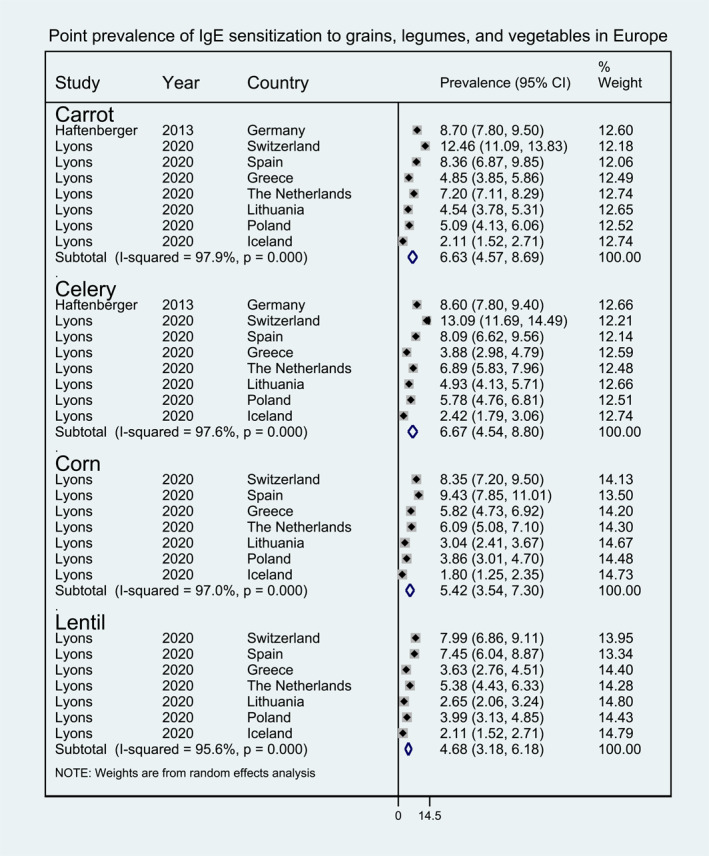



Paper: PMC10848175
Section: Frequency of FA
Caption: FIGURE 7 Point prevalence of immunoglobulin E sensitization to grains, legumes, and vegetables in Europe.
Placeholder: PMC_FIG_13



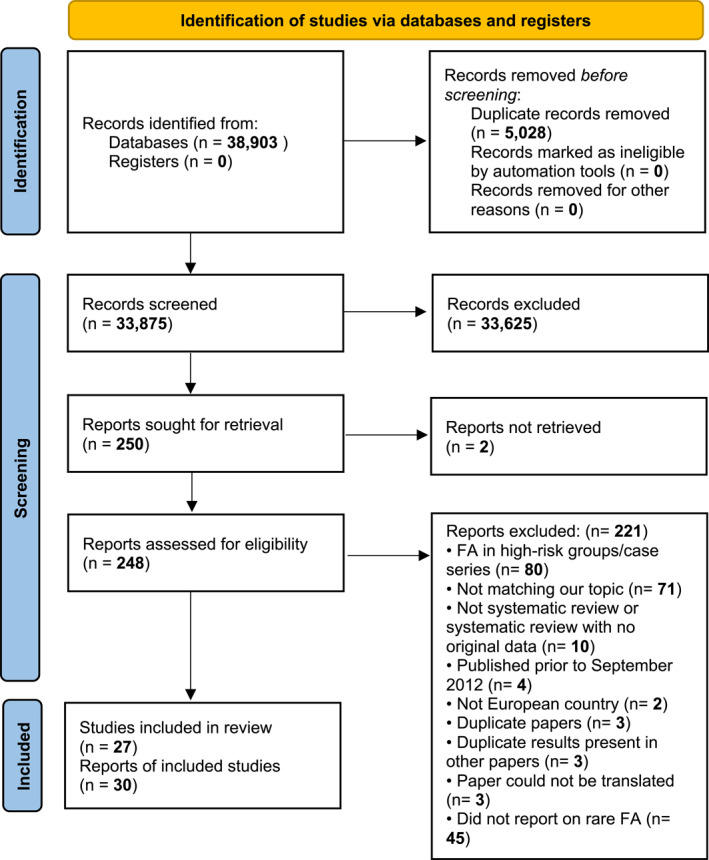



Paper: PMC10848175
Section: Frequency of FA
Caption: FIGURE 8 Point prevalence of immunoglobulin E sensitization to seeds in Europe.
Placeholder: PMC_FIG_14



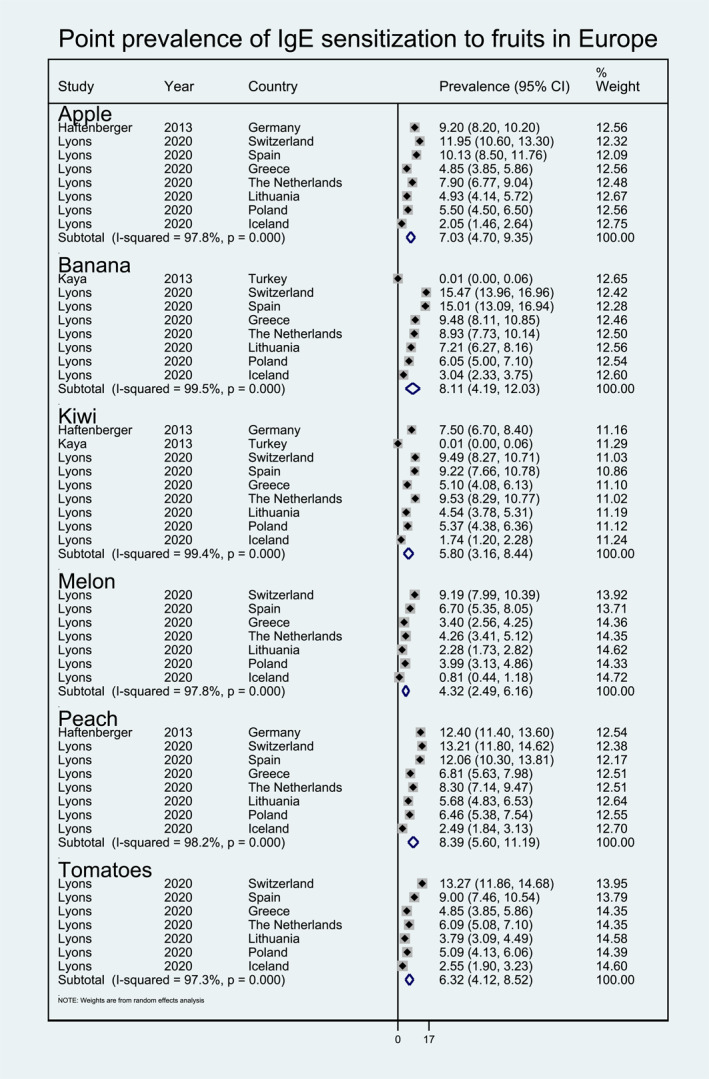

In [13]:
# Example 5: Display images from the export
if len(df_images) > 0:
    print(f"Total images in export: {len(df_images)}\n")
    print("Displaying 3 images from 20th position:\n")
    for i in range(min(20, len(df_images)), min(23, len(df_images))):
        show_image(i)
        print("\n" + "="*60 + "\n")


## Using Helper Functions

Use the helper functions below to inspect specific tables and images:

- `show_table(index)` — Display a specific table by index
- `show_image(index)` — Display a specific image by index
- `show_document(paper_id)` — Show metadata for a paper
- `show_document_sections(paper_id)` — Display all sections with tables and images

Examples:
```python
show_table(0)           # First table
show_image(0)           # First image
show_table(5)           # 6th table
show_image(3)           # 4th image
```
